In [1]:
!pip install nltk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
from sklearn.utils import shuffle
import string

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

import pickle
import joblib

In [5]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('popular')

nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzip

True

In [7]:
# 1. Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


Data loading......⏳
✅ Data Loaded Successfully!
Total Rows: 166418
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text  label  \
0  Donald Trump just couldn t wish all Americans ...      1   
1  House Intelligence Committee Chairman Devin Nu...      1   
2  On Friday, it was revealed that former Milwauk...      1   
3  On Christmas day, Donald Trump announced that ...      1   
4  Pope Francis used his annual Christmas Day mes...      1   

                                             content  
0   Donald Trump Sends Out Embarrassing New Year’...  
1   Drunk Bragging Trump Staffer Started Russian ...  
2   Sheriff David Clarke Becomes An Internet Joke...

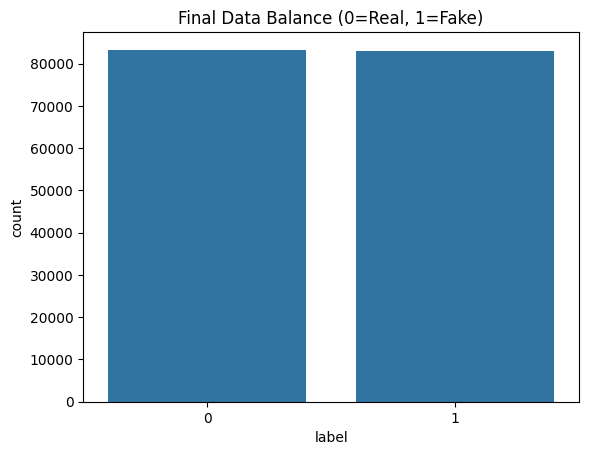

In [8]:
# 2. Load Final Cleaned Data
base_dir = '/content/drive/MyDrive/fake news project'
load_path = os.path.join(base_dir, "V2_cleaned kaggle datasets/final_dataset.csv")

print("Data loading......⏳")

try:
    df = pd.read_csv(load_path)
    # making the content column in the cleaned dataset in string type if it is not string
    df['content'] = df['content'].astype(str)

    print("✅ Data Loaded Successfully!")
    print(f"Total Rows: {df.shape[0]}")
    print(df.head())

    # Class Balance Check (Ek baar phir tasalli ke liye)
    sns.countplot(x='label', data=df)
    plt.title("Final Data Balance (0=Real, 1=Fake)")
    plt.show()

except FileNotFoundError:
    print("❌ Error: File not found")

## shuffling all the data in the df

In [9]:
# --- STEP 1: Final Shuffle ---
# Pure dataset ko achi tarah mix kar rahe hain
df = shuffle(df, random_state=42).reset_index(drop=True)
print("Data Shuffled Successfully!")

Data Shuffled Successfully!


## now applying NLP in content

### steps for NLP Preprocessing
    1. Transforming into Lowercase
    2. Removing Punctuations
    3. Removing number if required
    4. Removing links and tags
    5. Removing emoji and special characters
    6. Removing Stopwords
    7. Spelling Correction(Optional)
    8. Removing HTML Tags


In [10]:

''' note:- in this we are not removing the number from the content column'''
# making the fuction name clean_for_nlp

def clean_for_nlp(content):
  content=content.lower().strip() # 1.making all the content in lowercase
  content=content.translate(str.maketrans("","",string.punctuation))  # 2. Removing Punctuations
  # content=content.translate(str.maketrans("","",string.digits)) # 3. Trying for removing number from the content  if accuracy is less then i will not remove number from the content and then i will try
  content=re.sub(r'http\S+|www\.\S+', '', content) # 4. Removing URL from the content
  content=re.sub(r'<.*?>', '', content) # 5. Removing the HTML tags from the content(optional)
  return content

# applying function on the df datasets
df.content=df.content.apply(clean_for_nlp)

In [11]:
df.content.loc[1]

'bush ethics lawyer slams trump he can’t go ‘one week’ without obstructing justice video richard painter former ethics lawyer to president george w bush claims that president donald trump  weighing in  on his son donald trump jr s statement on meeting with a russian lawyer is yet another possible example of obstruction of justice by the us commander in chief painter even went as far as to say that obstruction of justice is a weekly occurrence for the trump administration i would like to have one week from this white house where they don t engage in a new act of obstruction of justice  painter said during an interview on msnbc s all in with chris hayes on tuesday eveningpainter also added that if trump jr has no problem using a false statement drafted by his father when dealing with the public then he would probably have the same disregard for the truth while taking the stand to testify on the situation during a criminal investigation once the son says something in a public statement he

In [12]:
# now removing the special character and the emoji

# Removing emoji and special character
def remove_emoji_and_specialchac(content):
    new=""
    for i in content:
        if i.isascii():
            new+=i
    return new
# applying the function

df.content=df.content.apply(remove_emoji_and_specialchac)

In [13]:
df.content.loc[1]

'bush ethics lawyer slams trump he cant go one week without obstructing justice video richard painter former ethics lawyer to president george w bush claims that president donald trump  weighing in  on his son donald trump jr s statement on meeting with a russian lawyer is yet another possible example of obstruction of justice by the us commander in chief painter even went as far as to say that obstruction of justice is a weekly occurrence for the trump administration i would like to have one week from this white house where they don t engage in a new act of obstruction of justice  painter said during an interview on msnbc s all in with chris hayes on tuesday eveningpainter also added that if trump jr has no problem using a false statement drafted by his father when dealing with the public then he would probably have the same disregard for the truth while taking the stand to testify on the situation during a criminal investigation once the son says something in a public statement he d 

In [14]:
#seeing the stopwords first
stopword=set(stopwords.words("english"))
print(f"stopwords:-{stopword}")
print(f"total number of stopwords:-{len(stopword)}")

stopwords:-{'once', 'he', 'couldn', "didn't", "haven't", 'ain', 'other', "she's", 'while', "they'd", 'will', 'herself', 'mightn', 'him', 'for', 'it', 'these', 'of', 'before', 'myself', 'haven', 'wasn', 'aren', 'very', 'is', "couldn't", 'in', 'too', 'them', 'do', 'at', "mightn't", 'can', "we'll", "wouldn't", 'those', 'the', "doesn't", "he'd", "he'll", 'or', 'who', 'no', "mustn't", 'yourself', "she'd", 'under', "we've", 'was', 'from', 'yourselves', "weren't", 'an', 'o', 'm', "shouldn't", "i'll", 'our', 'this', 'had', 'd', 'does', "needn't", 'further', 'she', "it'll", 'mustn', 'hasn', 'into', "i've", 'by', 'shan', "won't", 'they', 'so', "they've", 'same', 'being', 'and', 'me', 'i', 'nor', 'were', 'what', 'if', 'itself', 'only', 'when', 'again', 'didn', 'such', "wasn't", 'are', 'yours', "should've", 'theirs', 'above', 'own', 't', "they'll", 'then', 'whom', 'most', "she'll", 'll', "you'll", "hadn't", 'than', 'during', 'each', 'against', 'her', 'weren', 'with', "we're", 'where', 'until', 'be

In [14]:
lemmatizer = WordNetLemmatizer() # for lemmatization

In [15]:
#tokanizing the words and making the content stopwords free

def remove_stopwords(txt):
    words = word_tokenize(txt)
    clean_words = []
    for i in words:
        if i not in stopword:
            i = lemmatizer.lemmatize(i)
            clean_words.append(i)
    return " ".join(clean_words)

In [17]:
df.content=df.content.apply(remove_stopwords)

In [16]:
df.content.loc[1]

'bush ethics lawyer slams trump he cant go one week without obstructing justice video richard painter former ethics lawyer to president george w bush claims that president donald trump  weighing in  on his son donald trump jr s statement on meeting with a russian lawyer is yet another possible example of obstruction of justice by the us commander in chief painter even went as far as to say that obstruction of justice is a weekly occurrence for the trump administration i would like to have one week from this white house where they don t engage in a new act of obstruction of justice  painter said during an interview on msnbc s all in with chris hayes on tuesday eveningpainter also added that if trump jr has no problem using a false statement drafted by his father when dealing with the public then he would probably have the same disregard for the truth while taking the stand to testify on the situation during a criminal investigation once the son says something in a public statement he d 

## splitting the model in to 70:15:15

In [17]:
#splitting the dataset into 70:15:15
# 70% for training
#15% for validation
#15% for testing

X = df['content']  # Cleaned text
y = df['label']     # Labels

# 70% will be train and 30% will test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,      # 30% for validation + test
    random_state=42,
    stratify=y
)

# from 30% of testing splitting into 15:15 for validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    random_state=42,
    stratify=y_temp
)

# Check sizes
print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train: 116492 (70.0%)
Val:   24963 (15.0%)
Test:  24963 (15.0%)


## converting text(content) into the numbers

In [18]:
# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=20000,ngram_range=(1,2),stop_words='english',max_df=0.9,min_df=5)

# Train pe FIT
X_train_tfidf = tfidf.fit_transform(X_train)

# Val aur Test pe sirf TRANSFORM
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Val shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (116492, 20000)
Val shape: (24963, 20000)
Test shape: (24963, 20000)


## now training the model

In [19]:
# --- STEP 1: Define All 5 Models (With Best Hyperparameters) ---
clf_lr = LogisticRegression(max_iter=2000, C=2.0, class_weight='balanced', solver='liblinear')
clf_nb = MultinomialNB(alpha=0.5)
clf_dt = DecisionTreeClassifier(max_depth=20, random_state=42)
clf_rf = RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_split=5, min_samples_leaf=2, random_state=42, n_jobs=-1)
clf_xgb = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method='hist')
# --- FIX FOR LINEAR SVC ---
# LinearSVC ko CalibratedClassifierCV mein wrap kar rahe hain taaki ye probability de sake
base_svc = LinearSVC(C=1.0, dual=False, max_iter=2000)
clf_svc = CalibratedClassifierCV(base_svc)


In [20]:
# --- STEP 2: Create Voting Classifier (All 5 Included) ---
# 'soft' voting uses probabilities (accuracy usually better)

voting_clf=VotingClassifier(
    estimators=[
        ("lr",clf_lr),
        ("rf",clf_rf),
        ("svc",clf_svc),
        ("xgb",clf_xgb),
        ("nb",clf_nb),
        ("dt",clf_dt)
    ],
    voting="soft"
)


In [21]:
# --- STEP 3: Combine Everything in One List ---
all_models = {
    'Logistic Regression': clf_lr,
    'Naive Bayes': clf_nb,
    'Decision Tree': clf_dt,
    'Random Forest': clf_rf,
    'XGBoost': clf_xgb,
    "SVC":clf_svc,
    'Voting Classifier (All 6)': voting_clf
}



🚀 Maha-Training Started... (Grab a coffee, this will take time!) ☕

############################################################
🔄 Training & Evaluating: Logistic Regression...
############################################################
Logistic Regression       | 85.69%     | 85.50%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.85      0.87      0.86     12499
    Fake (1)       0.87      0.84      0.85     12464

    accuracy                           0.86     24963
   macro avg       0.86      0.86      0.85     24963
weighted avg       0.86      0.86      0.85     24963



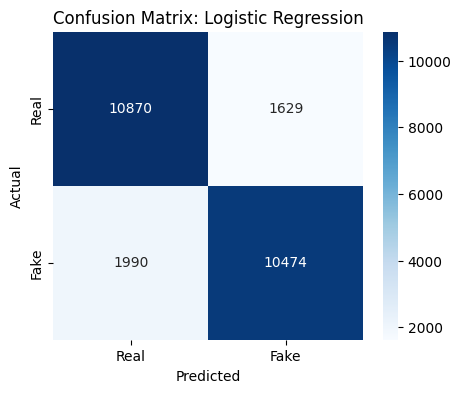


############################################################
🔄 Training & Evaluating: Naive Bayes...
############################################################
Naive Bayes               | 80.17%     | 80.41%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.79      0.84      0.81     12499
    Fake (1)       0.82      0.77      0.80     12464

    accuracy                           0.80     24963
   macro avg       0.81      0.80      0.80     24963
weighted avg       0.81      0.80      0.80     24963



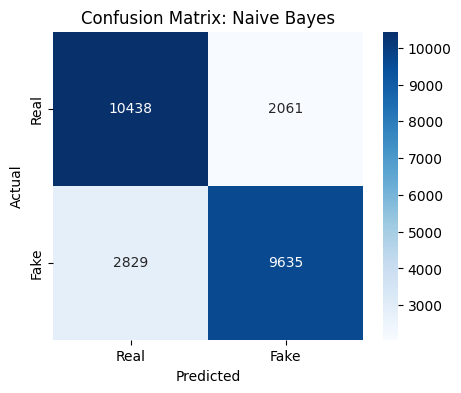


############################################################
🔄 Training & Evaluating: Decision Tree...
############################################################
Decision Tree             | 82.55%     | 82.73%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.77      0.94      0.84     12499
    Fake (1)       0.92      0.72      0.81     12464

    accuracy                           0.83     24963
   macro avg       0.84      0.83      0.83     24963
weighted avg       0.84      0.83      0.83     24963



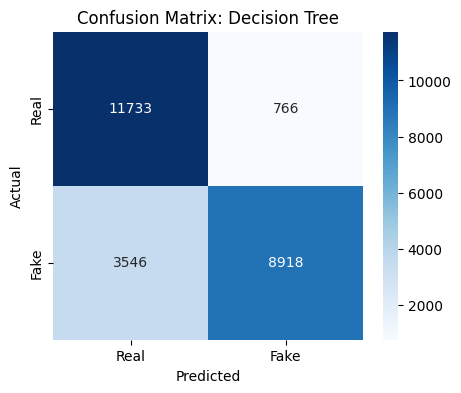


############################################################
🔄 Training & Evaluating: Random Forest...
############################################################
Random Forest             | 78.50%     | 79.09%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.71      0.98      0.82     12499
    Fake (1)       0.96      0.61      0.74     12464

    accuracy                           0.79     24963
   macro avg       0.84      0.79      0.78     24963
weighted avg       0.84      0.79      0.78     24963



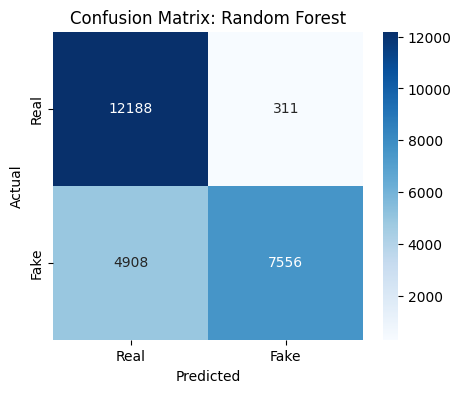


############################################################
🔄 Training & Evaluating: XGBoost...
############################################################
XGBoost                   | 83.28%     | 83.23%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.77      0.94      0.85     12499
    Fake (1)       0.92      0.73      0.81     12464

    accuracy                           0.83     24963
   macro avg       0.85      0.83      0.83     24963
weighted avg       0.85      0.83      0.83     24963



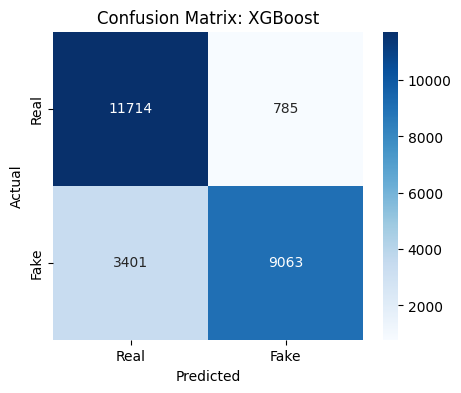


############################################################
🔄 Training & Evaluating: SVC...
############################################################
SVC                       | 85.73%     | 85.60%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.85      0.87      0.86     12499
    Fake (1)       0.86      0.85      0.85     12464

    accuracy                           0.86     24963
   macro avg       0.86      0.86      0.86     24963
weighted avg       0.86      0.86      0.86     24963



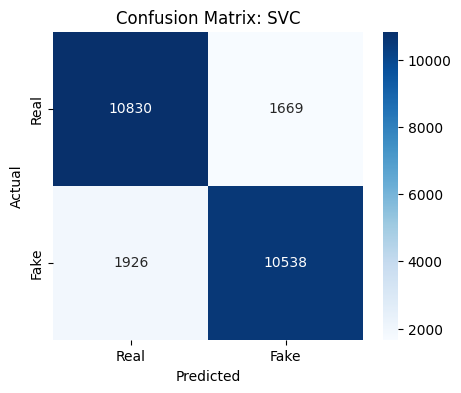


############################################################
🔄 Training & Evaluating: Voting Classifier (All 6)...
############################################################
Voting Classifier (All 6) | 86.06%     | 86.09%

📊 Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.82      0.92      0.87     12499
    Fake (1)       0.91      0.80      0.85     12464

    accuracy                           0.86     24963
   macro avg       0.87      0.86      0.86     24963
weighted avg       0.87      0.86      0.86     24963



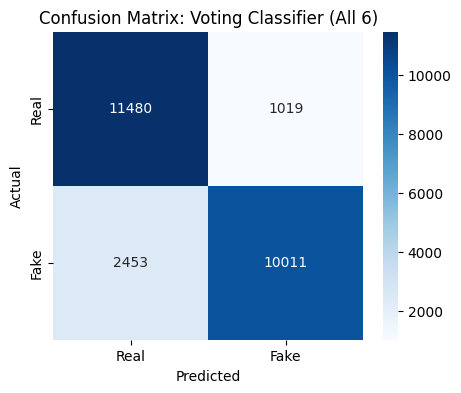

In [22]:
# --- STEP 4: The MEGA Loop (Training & Full Evaluation) ---
results = {}
print("🚀 Maha-Training Started... (Grab a coffee, this will take time!) ☕")

for name, model in all_models.items():
    print(f"\n{'#'*60}")
    print(f"🔄 Training & Evaluating: {name}...")
    print(f"{'#'*60}")

    # 1. Train
    model.fit(X_train_tfidf, y_train)

    # 2. Validation Prediction (Mock Test)
    # Model check kar raha hai ki jo seekha wo naye data pe chal raha hai ya nahi
    y_val_pred = model.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, y_val_pred)

    # 3. Test Prediction (Final Exam)
    y_test_pred = model.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Result Store
    results[name] = test_acc

    # Print Scores like a Table
    print(f"{name:<25} | {val_acc*100:.2f}%     | {test_acc*100:.2f}%")

    # 5. Detailed Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['Real (0)', 'Fake (1)']))

    # 6. Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()



In [23]:
# --- STEP 5: Final Leaderboard ---
print("\n" + "="*40)
print("🏆 FINAL ACCURACY LEADERBOARD 🏆")
print("="*40)
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for name, score in sorted_results:
    print(f"{name}: {score:.4f}")


🏆 FINAL ACCURACY LEADERBOARD 🏆
Voting Classifier (All 6): 0.8609
SVC: 0.8560
Logistic Regression: 0.8550
XGBoost: 0.8323
Decision Tree: 0.8273
Naive Bayes: 0.8041
Random Forest: 0.7909


## downloading the model named Logistic Regression , voting classifier and svc

In [24]:
# 1. Google Drive Mount Kar (Agar nahi hai)
drive.mount('/content/drive')

# 2. Folder Banao (Agar nahi hai)
save_dir = '/content/drive/MyDrive/fake news project/V2_Saved_Models_ML'
os.makedirs(save_dir, exist_ok=True)

print(f"📂 Saving files to: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Saving files to: /content/drive/MyDrive/fake news project/V2_Saved_Models_ML


In [25]:
# --- A. MODEL & VECTORIZER SAVE KARO ---
# 1. Voting Model
joblib.dump(voting_clf, os.path.join(save_dir, 'voting_classifier_86acc.pkl'))
print("✅ Voting Model Saved!")

joblib.dump(clf_lr,os.path.join(save_dir,"logistic_regression.pkl"))
print("✅ Voting Model Saved!")

joblib.dump(clf_svc,os.path.join(save_dir,"svc.pkl"))
print("✅ Voting Model Saved!")

# 2. TF-IDF Vectorizer (Iske bina model kaam nahi karega)
joblib.dump(tfidf, os.path.join(save_dir, 'tfidf_vectorizer.pkl'))
print("✅ Vectorizer Saved!")

✅ Voting Model Saved!
✅ Voting Model Saved!
✅ Voting Model Saved!
✅ Vectorizer Saved!


## checking whether the all the model are in underfitting , overfitting or good


In [26]:
# 1. Saare models ki ek list banao
models = {
    "Logistic Regression": clf_lr,
    "Naive Bayes": clf_nb,
    "Decision Tree": clf_dt,
    "Random Forest": clf_rf,
    "XGBoost": clf_xgb,
    "Linear SVC": clf_svc,
    "Voting Classifier": voting_clf
}

# 2. Accuracy calculate karne ke liye loop
results = []

print("📊 Evaluating Models... Please wait...")

for name, model in models.items():
    # Predictions
    train_preds = model.predict(X_train_tfidf)
    val_preds = model.predict(X_val_tfidf)
    test_preds = model.predict(X_test_tfidf)

    # Accuracies
    train_acc = accuracy_score(y_train, train_preds) * 100
    val_acc = accuracy_score(y_val, val_preds) * 100
    test_acc = accuracy_score(y_test, test_preds) * 100

    # Gap (Overfitting check karne ke liye)
    gap = train_acc - test_acc

    status = "Good"
    if train_acc < 70:
        status = "Underfitting (Needs more training)"
    elif gap > 10:
        status = "Overfitting (Ratta maar raha hai)"

    results.append({
        "Model Name": name,
        "Train Acc (%)": round(train_acc, 2),
        "Val Acc (%)": round(val_acc, 2),
        "Test Acc (%)": round(test_acc, 2),
        "Gap (Train-Test)": round(gap, 2),
        "Status": status
    })

# 3. Table format mein result dikhao
results_df = pd.DataFrame(results)
print("\n🔥 MODEL PERFORMANCE REPORT 🔥")
display(results_df)

📊 Evaluating Models... Please wait...

🔥 MODEL PERFORMANCE REPORT 🔥


,Model Name,Train Acc (%),Val Acc (%),Test Acc (%),Gap (Train-Test),Status
0,Logistic Regression,88.86,85.69,85.50,3.36,Good
1,Naive Bayes,81.19,80.17,80.41,0.78,Good
2,Decision Tree,84.99,82.55,82.73,2.27,Good
3,Random Forest,79.74,78.50,79.09,0.64,Good
4,XGBoost,84.17,83.28,83.23,0.94,Good
5,Linear SVC,90.43,85.73,85.60,4.83,Good
6,Voting Classifier,88.98,86.06,86.09,2.89,Good
